## CitySeer: Métricas Configuracionais do Espaço Urbano

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [1]:
# Standard library imports
import datetime as dt
import os
import pickle
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List

# Third-party library imports
from cityseer.metrics import layers, networks
from cityseer.tools import graphs, io
import contextily as cx
import geobr
import geopandas as gpd
from libpysal.cg import voronoi_frames
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import partridge as ptg
from shapely.geometry import Point
from tobler.area_weighted import area_interpolate
from tqdm import tqdm


INFO:numexpr.utils:Note: NumExpr detected 12 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
FOLDER = os.environ.get('OUT_FOLDER')

DATABASE = Path(FOLDER)

OUT_DIR = Path(FOLDER) / 'B/cityseer'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
MUNI_CODES = 3106200,

# Getting Valid Study Area

In [5]:
place = pd.concat([
    geobr.read_municipality(idx)
    for idx in MUNI_CODES
])

crs = place.estimate_utm_crs(datum_name='SIRGAS 2000')
place = place.to_crs(crs)

study_area_bounds = place.geometry.squeeze()
study_buffer = place.geometry.convex_hull.squeeze().buffer(15000)

# Graph Prepation

In [6]:
OUT_PICKLE    = (
    OUT_DIR
    / f"simplified_graph.gpickle"
    )


#with open(OUT_PICKLE, 'wb') as f:
#    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

with open(OUT_PICKLE, 'rb') as f:
    G = pickle.load(f)

In [7]:
for node_idx, node_data in G.nodes(data=True):
    node_pnt = Point(node_data["x"], node_data["y"])
    if node_pnt.intersects(study_area_bounds):
        G.nodes[node_idx]["live"] = True
    else:
        G.nodes[node_idx]["live"] = False

In [ ]:
G_dual = graphs.nx_to_dual(G)

INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
100%|██████████| 131314/131314 [00:06<00:00, 21438.75it/s]
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)
100%|██████████| 131314/131314 [06:29<00:00, 337.02it/s]


In [ ]:
# For mixed uses later on
nodes_gdf, _edges_gdf, network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.


100%|██████████| 131314/131314 [01:52<00:00, 1164.52it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 292672 items.


# Graph Metrics

In [ ]:
# Cutoffs from local to global
distances = [500, 1000, 1500, 2000, 2500, 5000, 7500, 10000, 15000]
distances = list(range(500, 10001, 250))

## Weighted Measures

In [11]:
def get_node_weights(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int = 31983
) -> pd.DataFrame:
    """
    Impute attributes from a GeoDataFrame to nodes in an OSMnx graph.

    Returns:
    - DataFrame with attr_cols, indexed as nodes
    """
    gdf, geom_types = validate_input_gdf(gdf, attr_cols)
    node_polygons = create_voronoi_polygons(nodes, study_area, out_crs)

    geometry_handlers = {
        frozenset({'Polygon', 'MultiPolygon'}): handle_polygons_with_area_interpolation,
        frozenset({'Point', 'MultiPoint'}): handle_points_with_spatial_join,
    }

    for geom_type_set, handler in geometry_handlers.items():
        if geom_types.issubset(geom_type_set):
            # Call the handler, but only keep attr_cols and index
            result = handler(nodes.copy(), gdf, node_polygons, attr_cols, out_crs)
            return result[attr_cols]

    raise ValueError("Tipo de geometria não suportado no GeoDataFrame.")


def validate_input_gdf(
    gdf: gpd.GeoDataFrame, attr_cols: List[str]
) -> tuple[gpd.GeoDataFrame, set[str]]:
    """Validate the input GeoDataFrame and attribute columns."""
    if gdf.empty:
        raise ValueError("O GeoDataFrame de entrada está vazio.")

    dropped_count = gdf.loc[gdf.geometry.isnull()].shape[0]
    if dropped_count > 0:
        print(
            f"Aviso: {dropped_count} geometria(s) foram descartadas por serem "
            "nulas."
        )
    gdf = gdf.loc[gdf.geometry.notnull()]
    gdf = gdf.fillna(0)
    geom_types = set(gdf.geometry.geom_type.unique())

    for col in attr_cols:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
        if gdf[col].isnull().any():
            invalid_entries = gdf.loc[gdf[col].isnull(), col]
            if not invalid_entries.empty:
                print(
                    f"Aviso: A coluna '{col}' contém entradas inválidas que "
                    f"não puderam ser convertidas para valores numéricos: "
                    f"{invalid_entries.tolist()}"
                )

    return gdf, geom_types


def create_voronoi_polygons(
    nodes: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    out_crs: str | int
) -> gpd.GeoDataFrame:
    """Create Voronoi polygons around nodes."""
    return voronoi_frames(
        nodes.to_crs(out_crs),
        clip=study_area,
        return_input=False,
        as_gdf=True,
    )


def handle_polygons_with_area_interpolation(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle polygons using area interpolation."""
    interpolated = area_interpolate(
        source_df=gdf.to_crs(out_crs),
        target_df=node_polygons,
        extensive_variables=attr_cols,
        allocate_total=True,
    )
    for col in attr_cols:
        nodes[col] = interpolated[col].to_numpy()
    return nodes


def handle_points_with_spatial_join(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle points using spatial join and dissolve."""
    gdf = gdf.to_crs(out_crs)
    joined = gpd.sjoin(node_polygons, gdf, how="left", predicate="contains")
    dissolved = joined.groupby(joined.index).agg(
        {col: "sum" for col in attr_cols}
    )
    for col in attr_cols:
        nodes[col] = dissolved[col].to_numpy()
    return nodes


In [12]:
input_path = (
    DATABASE
    / 'A/sociodemografia/sociodemografia.parquet'
    )
pop_by_hex = gpd.read_parquet(input_path).xs(key=2022, level='year').to_crs(31983)

pop_by_hex = pop_by_hex.to_crs(crs)

pop_by_hex['massa_salarial_pessoas'] = pop_by_hex['habitantes'] * pop_by_hex['rendimento_medio']
pop_by_hex['massa_salarial_domicilios'] = pop_by_hex['domicilios'] * pop_by_hex['rendimento_medio']

In [13]:
input_path = (
    DATABASE
    / 'A/oportunidades/rais/rais_treated.parquet'
    )
rais = gpd.read_parquet(input_path)

rais = rais.query(
    'grupo_cnae not in ["T", "U"] and '
    '(sector != "business_services_secondary" or grupo_cnae == "P")'
)

rais = rais.dropna(subset=['cnae_2']) # just in case

In [14]:
node_data = {
    'osmid': list(G_dual.nodes()),
    'x': [data['x'] for node, data in G_dual.nodes(data=True)],
    'y': [data['y'] for node, data in G_dual.nodes(data=True)],
}
# Create node GeoDataFrame
node_gdf = gpd.GeoDataFrame(
    node_data,
    crs=31983,
    geometry=gpd.points_from_xy(node_data['x'], node_data['y'])
    )
node_gdf = node_gdf.set_index('osmid')

In [15]:
node_gdf['habitantes'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['habitantes'],
    out_crs=31983,
)

node_gdf['domicilios'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['domicilios'],
    out_crs=31983,
)

node_gdf['massa_salarial_pessoas'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['massa_salarial_pessoas'],
    out_crs=31983,
)

node_gdf['massa_salarial_domicilios'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['massa_salarial_domicilios'],
    out_crs=31983,
)

node_gdf['estabelecimentos'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    rais.assign(estabelecimentos=1),
    study_area_bounds.buffer(1_000),
    attr_cols=['estabelecimentos'],
    out_crs=31983,
)

node_gdf['weight'] = node_gdf.habitantes

In [16]:
OUT_PARQUET    = (
    OUT_DIR
    / f"node_gdf.parquet"
    )

node_gdf = node_gdf.loc[node_gdf.intersects(study_area_bounds)]

node_gdf.to_parquet(
    OUT_PARQUET
)

In [17]:
nbunch = {
    k: {'weight': v}
    for k, v in node_gdf.weight.to_dict().items()
    }

nx.set_node_attributes(
    G_dual,
    nbunch,
)

In [18]:
weighted_nodes_gdf, _weighted_edges_gdf, weighted_network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 131314/131314 [01:11<00:00, 1828.77it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 292672 items.


### Shortest Distance

In [19]:
weighted_nodes_gdf = networks.node_centrality_shortest(
    network_structure=weighted_network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 131314/131314 [1:18:10<00:00, 28.00it/s] 
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 750m, Beta: 0.00533, Walking Time: 9.383333333333333 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1250m, Beta: 0.0032, Walking Time: 15.633333333333333 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 1750m, Beta: 0.00229, Walking Time: 21.883333333333333 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2250m, Beta: 0.00178, Walking Time: 28.133333333333333 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 2750m, Beta: 0.0014

### Angular Distances

In [20]:
weighted_nodes_gdf = networks.node_centrality_simplest(
    network_structure=weighted_network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 131314/131314 [30:06<00:00, 72.67it/s]  
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 750m, Beta: 0.00533, Walking Time: 9.383333333333333 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1250m, Beta: 0.0032, Walking Time: 15.633333333333333 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 1750m, Beta: 0.00229, Walking Time: 21.883333333333333 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2250m, Beta: 0.00178, Walking Time: 28.133333333333333 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 2750m, Beta: 0.00145

In [21]:
from sklearn.preprocessing import minmax_scale

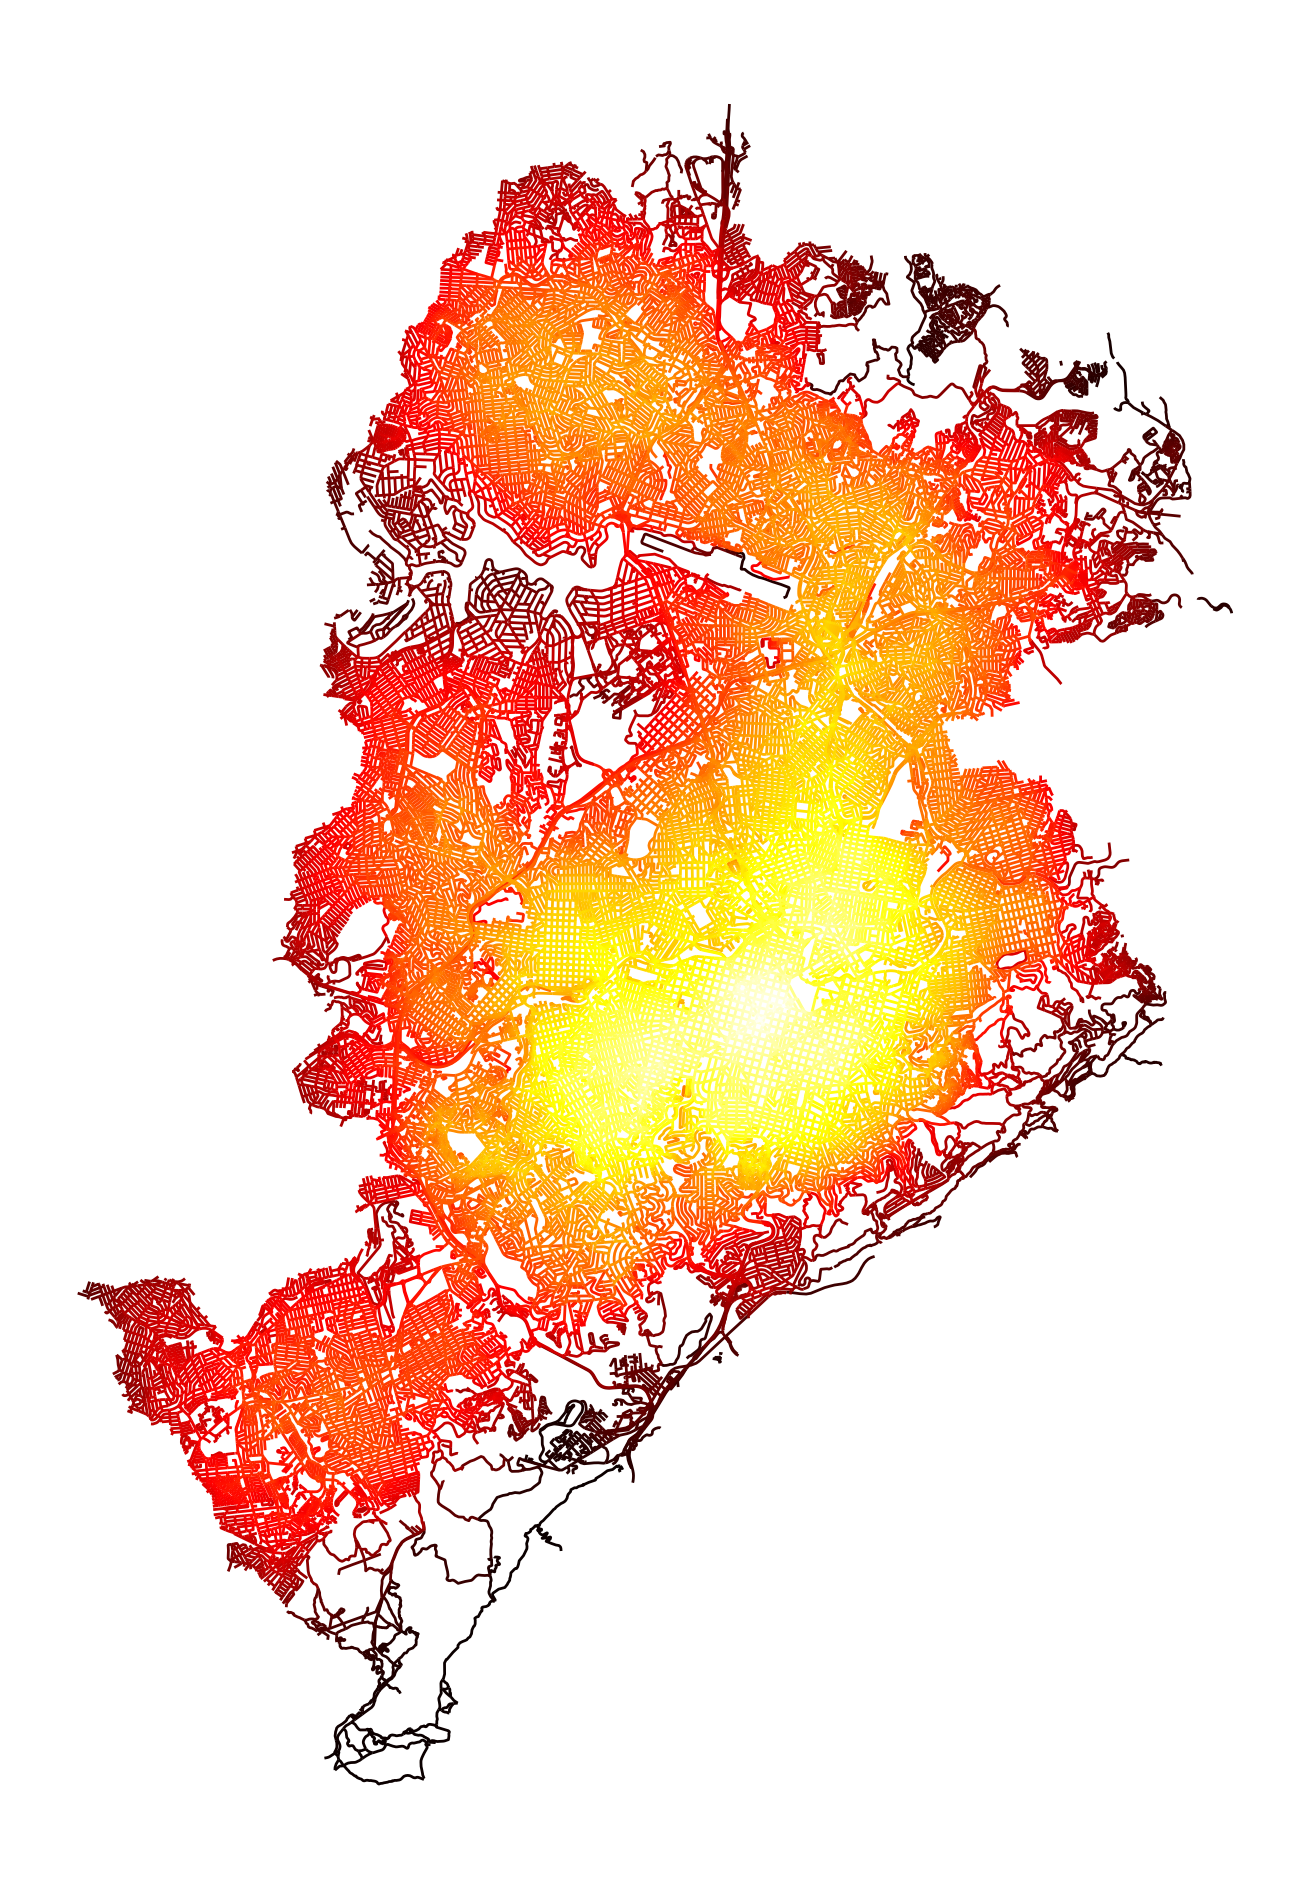

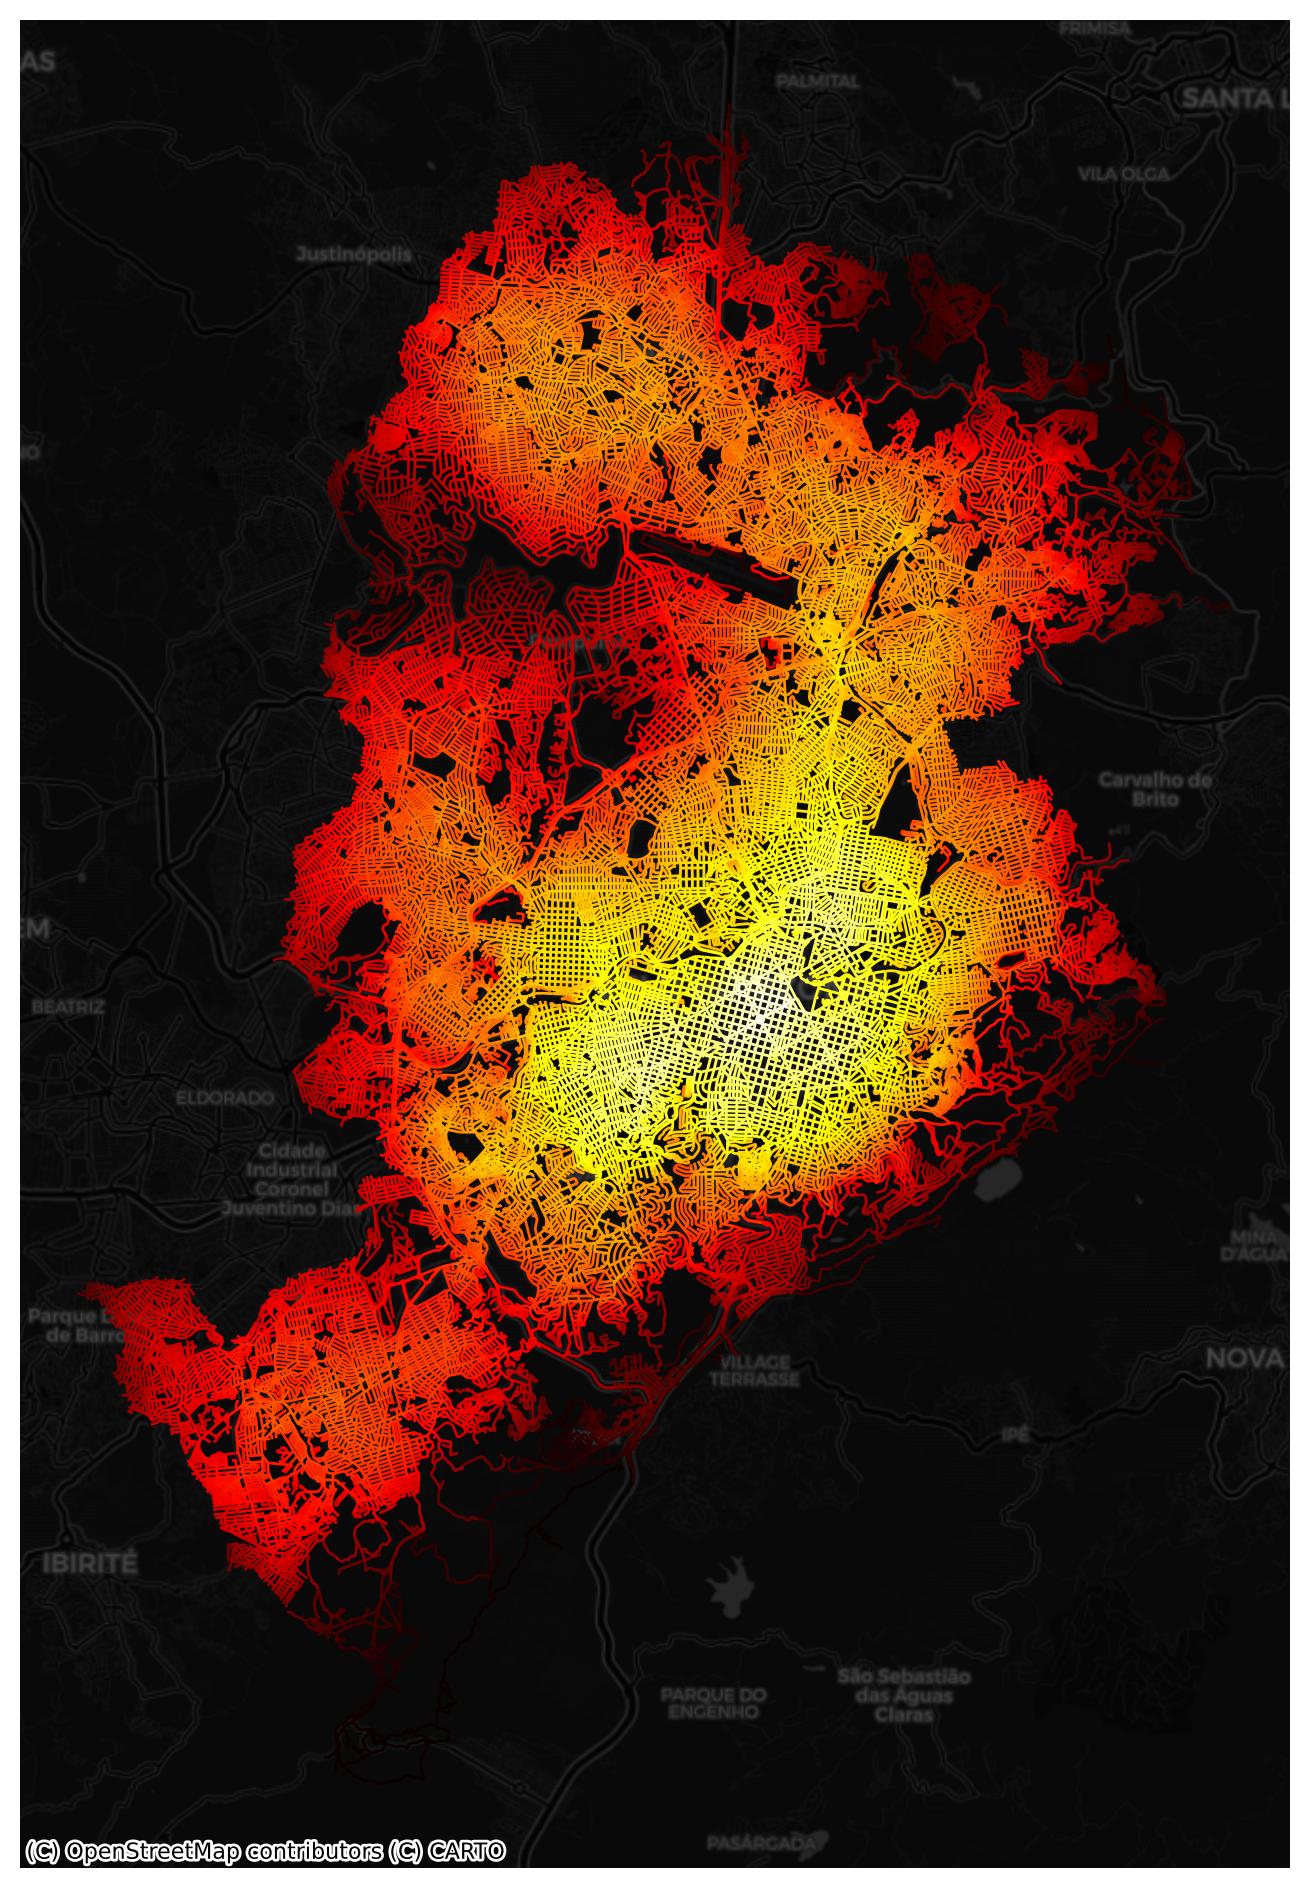

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_harmonic_5000"
db = weighted_nodes_gdf.query("live == True").sort_values(metric)
db[metric] = minmax_scale(db[metric])
db.plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="hot",
    #cmap='inferno',
    legend=False,
    #scheme='NaturalBreaks',
    ax=ax,
    linewidth=1,
)

ax.axis(False)
cx.add_basemap(
    ax=ax,
    crs=weighted_nodes_gdf.crs,
    source=cx.providers.CartoDB.DarkMatter,
)

plt.show()

## GTFS

In [24]:
# For keeping track of the centrality without GTFS
new_cols = {}
for col in weighted_nodes_gdf.columns:
    if col.startswith("cc_"):
        new_cols[f"{col}_not"] = weighted_nodes_gdf[col]

weighted_nodes_gdf = pd.concat(
    [
        weighted_nodes_gdf,
        pd.DataFrame(new_cols, index=weighted_nodes_gdf.index)
    ],
    axis=1,
    )

In [25]:
inpath = DATABASE / 'B/GTFSBHTRANS.zip'

In [26]:
# =========================== configuration ================================= #

@dataclass(frozen=True)
class GtfsConfig:
    analysis_date: str | dt.date | None = None
    window_start_hms: str = "06:00:00"
    window_end_hms: str = "08:00:00"
    window_pad_hms: str | None = None
    route_types: Iterable[int] | None = None
    route_ids: Iterable[str] | None = None
    linking_radius_m: float = 400.0
    min_segment_s: int = 5
    max_segment_s: int = 4 * 3600
    feed_tag: str | None = 'gtfs'
    # expected wait from union of arrivals at stop (board-first-vehicle)
    compute_expected_wait: bool = True
    expected_wait_by_direction: bool = False
    use_time_aware_edges: bool = False


# ============================= utilities =================================== #

def parse_hms_to_seconds(time: str | float | int | None) -> float | None:
    """Return seconds-from-midnight when given float/int or 'HH:MM:SS'.
    HH may be >=24. Return None on NaN or invalid.
    """
    # Fast path: numeric seconds already provided by Partridge
    if pd.isnull(time):
        return None
    if isinstance(time, (int, float)):
        return float(time) if np.isfinite(time) else None

    # Fallback: parse 'HH:MM:SS'
    try:
        hh, mm, ss = str(time).split(":")
        return float(int(hh) * 3600 + int(mm) * 60 + int(ss))
    except Exception:
        return None


def choose_date_or_busiest(inpath: str,
                           date_opt: str | dt.date | None) -> dt.date:
    """Pick date; default to Partridge busiest date."""
    if date_opt is None:
        date, _ = ptg.read_busiest_date(inpath)
        return date
    return pd.to_datetime(date_opt).date()


def build_partridge_view(inpath: str,
                         chosen_date: dt.date,
                         route_types: Iterable[int] | None,
                         route_ids: Iterable[str] | None) -> dict[str, dict]:
    """View filters: active services for date, plus route constraints."""
    sids_by_date = ptg.read_service_ids_by_date(inpath)
    service_ids = sids_by_date.get(chosen_date, None)
    trips_view = {"service_id": service_ids} if service_ids else {}
    routes_view: dict[str, list] = {}
    if route_types is not None:
        routes_view["route_type"] = list(route_types)
    if route_ids is not None:
        routes_view["route_id"] = list(route_ids)
    return {"trips.txt": trips_view, "routes.txt": routes_view}


def load_gtfs_with_view(inpath: str | Path,
                        view: dict[str, dict]) -> tuple[pd.DataFrame, ...]:
    """Load Partridge feed and return core tables."""
    feed = ptg.load_geo_feed(str(inpath), view=view)
    stops_gdf = feed.stops.copy()
    stop_times_gdf = feed.stop_times.copy()
    trips_df = feed.trips.copy()
    if stops_gdf.empty or stop_times_gdf.empty or trips_df.empty:
        raise ValueError("Empty GTFS view after filters.")
    return stops_gdf, stop_times_gdf, trips_df, getattr(feed, "frequencies", None)


def parse_stop_times(stop_times_gdf: pd.DataFrame) -> pd.DataFrame:
    """Add *_time_s in seconds; support HH>=24."""
    out = stop_times_gdf.copy()
    for name in ("arrival_time", "departure_time"):
        col = f"{name}_s"
        if name in out.columns:
            out[col] = out[name].map(parse_hms_to_seconds)
        else:
            out[col] = np.nan
    if "stop_sequence" not in out.columns:
        raise ValueError("stop_times missing stop_sequence.")
    out["stop_sequence"] = pd.to_numeric(
        out["stop_sequence"], errors="coerce"
    ).astype("Int64")
    return out


def interpolate_trip_departures(stop_times_df: pd.DataFrame) -> pd.DataFrame:
    """
    Per-trip linear interpolation of departure_time_s for internal gaps.
    Leaves trailing NaNs (e.g., last stop). Requires sorted stop_sequence.
    """
    st = stop_times_df.copy()
    if "departure_time_s" not in st:
        raise ValueError("departure_time_s is required.")
    st = st.sort_values(["trip_id", "stop_sequence"])

    def _interp_one_trip(g: pd.DataFrame) -> pd.DataFrame:
        vals = g["departure_time_s"].to_numpy(dtype=float)
        idxs = np.arange(vals.size)
        known = ~np.isnan(vals)
        if known.sum() < 2:
            return g
        last_known = idxs[known][-1]
        mask = idxs <= last_known
        x = idxs[mask]
        y = vals[mask]
        good = ~np.isnan(y)
        if good.sum() >= 2:
            y[~good] = np.interp(x[~good], x[good], y[good])
        vals[mask] = y
        g["departure_time_s"] = vals
        return g

    st = st.groupby("trip_id", group_keys=False).apply(_interp_one_trip)
    return st


def compute_segment_times(stop_times_df: pd.DataFrame) -> pd.DataFrame:
    """
    Per-trip segment time: dep_i -> arr_{i+1}. Returns one row per next stop.
    """
    st = stop_times_df.sort_values(["trip_id", "stop_sequence"]).copy()
    st["prev_departure_s"] = st.groupby("trip_id")["departure_time_s"].shift()
    st["prev_stop_id"] = st.groupby("trip_id")["stop_id"].shift()
    good = (
        st["prev_stop_id"].notna() &
        st["prev_departure_s"].notna() &
        st["arrival_time_s"].notna()
    )
    st = st.loc[good].copy()
    st["segment_time_s"] = (st["arrival_time_s"] - st["prev_departure_s"]) \
                           .astype(int)
    cols = ["trip_id",
            "prev_stop_id",
            "stop_id",
            "segment_time_s",
            "arrival_time_s",
            "prev_departure_s"]
    return st[cols]


def select_time_window(df: pd.DataFrame,
                       time_col_s: str,
                       start_hms: str,
                       end_hms: str,
                       pad_hms: str | None = None) -> pd.DataFrame:
    """Filter rows whose time lies in [start, end + pad]."""
    start_s = parse_hms_to_seconds(start_hms) or 0
    end_s = parse_hms_to_seconds(end_hms) or 24 * 3600
    pad_s = 0 if pad_hms is None else (parse_hms_to_seconds(pad_hms) or 0)
    return df[(df[time_col_s] >= start_s) & (df[time_col_s] <= end_s + pad_s)]


def compute_expected_wait_any_vehicle(stop_times_df: pd.DataFrame,
                                      trips_df: pd.DataFrame,
                                      window_start_hms: str,
                                      window_end_hms: str,
                                      by_direction: bool = False
                                      ) -> pd.DataFrame:
    """
    Expected wait from union of arrivals per stop (half mean inter-arrival).
    """
    st = stop_times_df.merge(
        trips_df[["trip_id", "route_id", "direction_id"]],
        on="trip_id", how="left"
    )
    event_time_s = st["arrival_time_s"].fillna(st["departure_time_s"])
    st = st.assign(event_time_s=event_time_s)
    ws = parse_hms_to_seconds(window_start_hms) or 7 * 3600
    we = parse_hms_to_seconds(window_end_hms) or 10 * 3600
    mask = (st["event_time_s"] >= ws) & (st["event_time_s"] <= we)
    st = st.loc[mask].copy()
    if st.empty:
        cols = ["stop_id", "expected_wait_s"]
        if by_direction:
            cols.insert(1, "direction_id")
        return pd.DataFrame(columns=cols)
    keys = ["stop_id", "direction_id"] if by_direction else ["stop_id"]
    st = st.sort_values(keys + ["event_time_s"])
    st["interarrival_s"] = st.groupby(keys)["event_time_s"].diff()
    mean_gap = (
        st.dropna(subset=["interarrival_s"])
        .groupby(keys)["interarrival_s"].mean()
        .rename("mean_interarrival_s")
        .reset_index()
    )
    ew = mean_gap.copy()
    ew["expected_wait_s"] = 0.5 * ew["mean_interarrival_s"]
    return ew[keys + ["expected_wait_s"]]


def namespace_stop_ids(stops_gdf: gpd.GeoDataFrame,
                       segments_df: pd.DataFrame,
                       feed_tag: str | None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Optionally prefix stop IDs to avoid collisions."""
    s_gdf = stops_gdf.copy()
    st_df = segments_df.copy()

    prefix = (feed_tag + ":") if feed_tag else ""

    for col in s_gdf.filter(like="stop_id").columns:
        s_gdf[col] = prefix + s_gdf[col].astype(str)

    for col in st_df.filter(like="stop_id").columns:
        st_df[col] = prefix + st_df[col].astype(str)

    return s_gdf, st_df


def subset_active_stops(stops_gdf: pd.DataFrame,
                        used_stop_ids: Iterable[str]) -> pd.DataFrame:
    """Keep only stops that appear in the used set."""
    return stops_gdf[stops_gdf["stop_id"].isin(list(used_stop_ids))].copy()


def project_stop_coords_geopandas(stops_gdf: pd.DataFrame,
                                  target_crs) -> pd.DataFrame:
    """Project lon/lat to target CRS via GeoPandas."""
    out = stops_gdf.to_crs(target_crs) if target_crs else stops_gdf.copy()
    out["x"] = out.geometry.x.astype(float)
    out["y"] = out.geometry.y.astype(float)
    return out


def add_stops_to_cityseer(cityseer_net: object,
                          stops_df: pd.DataFrame,
                          linking_radius_m: float) -> dict[str, int]:
    """Create transport nodes; return map stop_id -> node index."""
    idx_map: dict[str, int] = {}
    for row in tqdm(stops_df.itertuples(index=False), total=len(stops_df)):
        wait_s = None if ("expected_wait_s" not in stops_df.columns or
                          pd.isna(row.expected_wait_s)) else \
                 float(row.expected_wait_s)
        node_idx = cityseer_net.add_transport_node(
            row.stop_id,
            float(row.x),
            float(row.y),
            linking_radius=float(linking_radius_m),
            #expected_wait_s=wait_s,
        )
        idx_map[row.stop_id] = node_idx
    return idx_map


def add_segments_to_cityseer(cityseer_net: object,
                             segments_df: pd.DataFrame,
                             stop_idx: dict[str, int],
                             min_segment_s: int,
                             max_segment_s: int,
                             use_time_aware_edges: bool) -> None:
    """Add directed edges where both endpoints exist; clip outliers."""
    seg = segments_df.copy()
    seg = seg[seg["segment_time_s"] >= int(min_segment_s)]
    seg.loc[seg["segment_time_s"] > int(max_segment_s), "segment_time_s"] = \
        int(max_segment_s)
    
    # aggregate per observed direction
    agg_cols = ["prev_stop_id", "stop_id"]
    if use_time_aware_edges:
        # when time-aware, avoid aggregating dep/arr; keep medians of time
        pass  # deliberate: store only travel_time below
    seg_mean = (
        seg.groupby(agg_cols, as_index=False)["segment_time_s"].median()
    )
    for row in tqdm(seg_mean.itertuples(index=False), total=len(seg_mean)):
        u = stop_idx.get(row.prev_stop_id)
        v = stop_idx.get(row.stop_id)
        if u is None or v is None:
            continue
        travel_time_s = float(row.segment_time_s)
        # metadata can be extended with dep/arr arrays if backend supports
        cityseer_net.add_transport_edge(
            u, v, 0, "na_gtfs", "na_gtfs", travel_time_s, None
        )


# ============================ orchestrator ================================= #

def integrate_gtfs_cityseer(inpath: str | Path,
                            cityseer_net: object,
                            target_crs: str | int = 31983,
                            cfg: GtfsConfig = GtfsConfig()) -> None:
    """
    Build CitySeer transit layer from GTFS with interpolation and windowing.
    """
    inpath = str(inpath)

    # 1) select date and load feed
    chosen_date = choose_date_or_busiest(inpath, cfg.analysis_date)
    view = build_partridge_view(
        inpath, chosen_date, cfg.route_types, cfg.route_ids
    )
    stops_gdf, stop_times_df, trips_df, _freqs = load_gtfs_with_view(
        inpath, view
    )

    # 2) parse times and interpolate internal departures
    stop_times_df = parse_stop_times(stop_times_df)
    stop_times_df = interpolate_trip_departures(stop_times_df)

    # 3) segment times per link (dep_i -> arr_{i+1})
    segments_df = compute_segment_times(stop_times_df)

    # 4) optional time window (pad applied to departure at from-stop)
    segments_df = select_time_window(
        segments_df,
        time_col_s="prev_departure_s",
        start_hms=cfg.window_start_hms,
        end_hms=cfg.window_end_hms,
        pad_hms=cfg.window_pad_hms
    )

    # 5) active stops subset (only those in segments)
    used_ids = pd.unique(
        pd.concat([segments_df["prev_stop_id"], segments_df["stop_id"]])
    )
    stops_gdf = subset_active_stops(stops_gdf, used_ids)

    # 6) expected wait (union of arrivals) if requested
    if cfg.compute_expected_wait:
        ew_df = compute_expected_wait_any_vehicle(
            stop_times_df,
            trips_df,
            cfg.window_start_hms,
            cfg.window_end_hms,
            by_direction=cfg.expected_wait_by_direction
        )
        stops_gdf = stops_gdf.merge(ew_df, on="stop_id", how="left")

    # 7) namespace ids and project to road CRS
    stops_gdf, segments_df = namespace_stop_ids(
        stops_gdf, segments_df, cfg.feed_tag
    )
    
    #return stops_gdf, segments_df

    stops_gdf = project_stop_coords_geopandas(stops_gdf, target_crs)

    # 8) write nodes then edges into CitySeer
    stop_idx = add_stops_to_cityseer(
        cityseer_net, stops_gdf, cfg.linking_radius_m
    )

    add_segments_to_cityseer(
        cityseer_net,
        segments_df,
        stop_idx,
        cfg.min_segment_s,
        cfg.max_segment_s,
        cfg.use_time_aware_edges
    )

    # 9) finalize network
    cityseer_net.validate()
    cityseer_net.build_edge_rtree()

    return cityseer_net


In [27]:
weighted_network_structure = integrate_gtfs_cityseer(
    inpath,
    cityseer_net=weighted_network_structure,
)

c:\Users\brand\anaconda3\envs\roda\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\brand\AppData\Local\Temp\ipykernel_11064\632150924.py:122: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  st = st.groupby("trip_id", group_keys=False).apply(_interp_one_trip)
100%|██████████| 12322/12322 [00:00<00:00, 145759.02it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 292672 i

In [ ]:
weighted_nodes_gdf = networks.node_centrality_shortest(
    network_structure=weighted_network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances, 
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
  0%|          | 0/131314 [00:00<?, ?it/s]

 78%|███████▊  | 102126/131314 [2:52:18<3:32:11,  2.29it/s] 

In [ ]:
weighted_nodes_gdf = networks.node_centrality_simplest(
    network_structure=weighted_network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances, 
)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_harmonic_5000"
db = weighted_nodes_gdf.query("live == True").sort_values(metric)

db.plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="hot",
    #cmap='inferno',
    legend=False,
    #scheme='NaturalBreaks',
    ax=ax,
    linewidth=1,
)

ax.axis(False)
cx.add_basemap(
    ax=ax,
    crs=weighted_nodes_gdf.crs,
    source=cx.providers.CartoDB.DarkMatter,
)

plt.show()

In [ ]:
OUT_PARQUET    = (
    OUT_DIR
    / f"weighted_centrality_by_households.parquet"
    )

weighted_nodes_gdf.to_parquet(
    OUT_PARQUET
)

#weighted_nodes_gdf = gpd.read_parquet(
#    OUT_PARQUET
#)

# Diversity

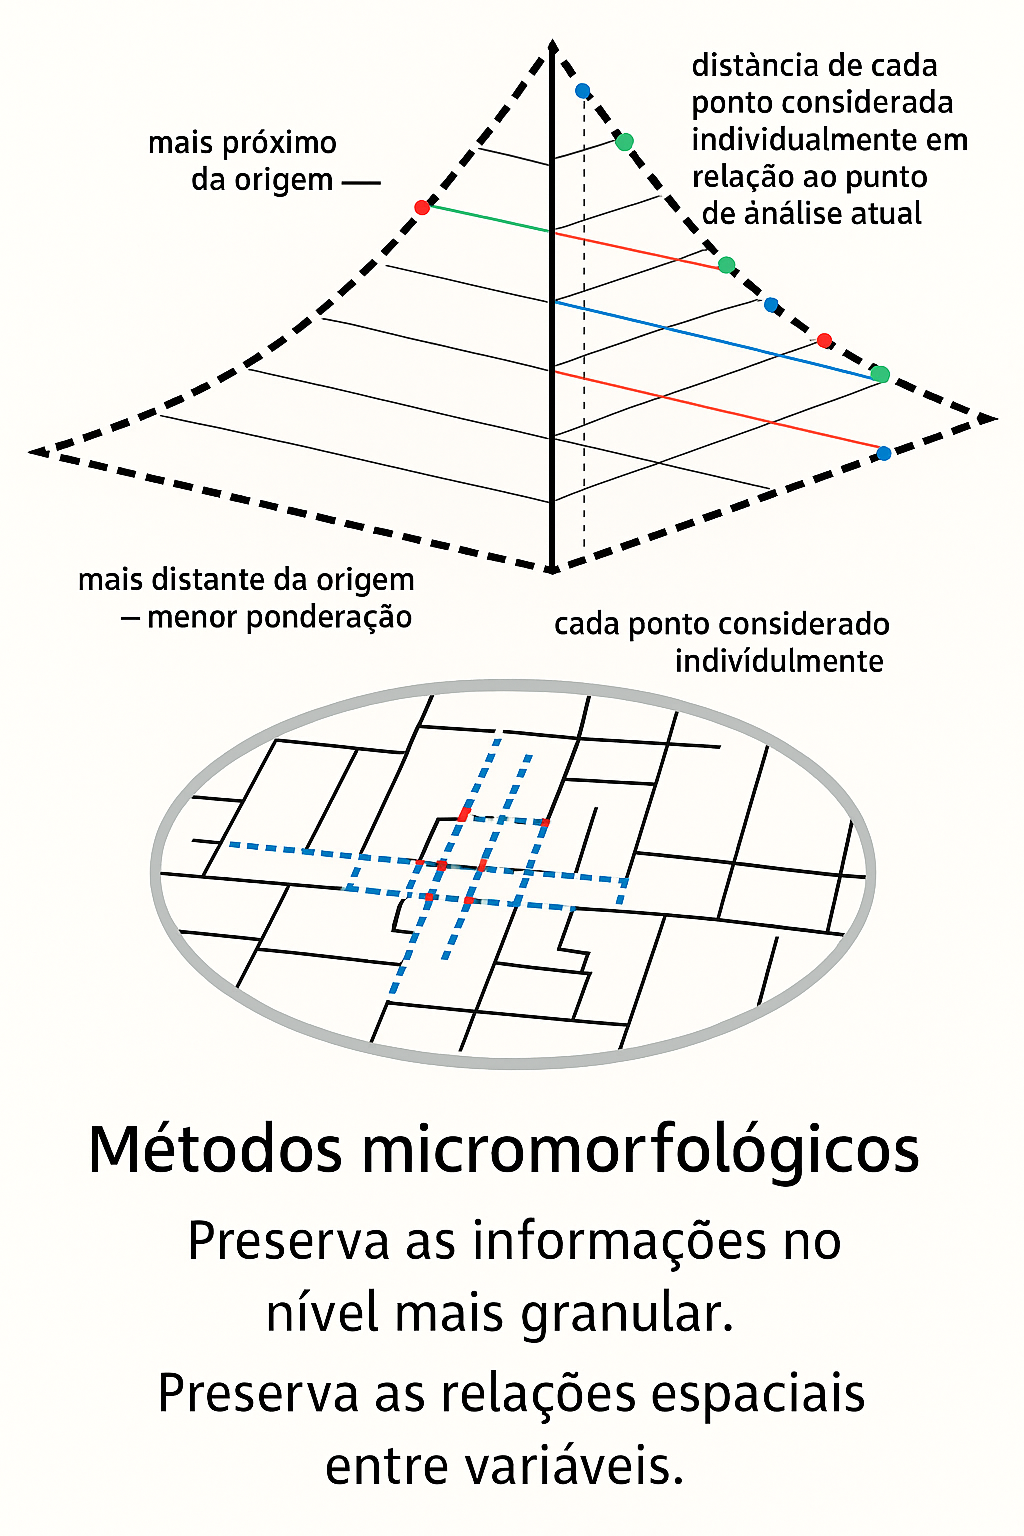

In [ ]:
distances = list(range(500, 1501, 250))

In [ ]:
nodes_gdf, rais = layers.compute_mixed_uses(
    rais,
    landuse_column_label="cnae_2",
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=distances,
)

In [ ]:
input_path = (
    DATABASE
    / 'A/oportunidades/rais/rais_treated.parquet'
    )
rais = gpd.read_parquet(input_path)

rais = rais.query(
    'grupo_cnae not in ["T", "U"] and '
    '(sector == "business_services_secondary" and grupo_cnae != "P")'
)

In [ ]:
nodes_gdf, rais = layers.compute_accessibilities(
    rais,
    landuse_column_label="sector",
    accessibility_keys=["business_services_secondary"],
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=distances,
)

In [ ]:
metric = "cc_hill_q1_500_wt"

fig, ax = plt.subplots(1, 1, figsize=(8, 16), facecolor="#1d1d1d")
nodes_gdf.query("live == True").sort_values(metric).plot(
    column=metric,
    cmap="hot",
    legend=False,
    ax=ax,
    linewidth=.75,
)

ax.axis(False)
plt.show()

In [ ]:
metric = "cc_business_services_secondary_250_nw"

fig, ax = plt.subplots(1, 1, figsize=(8, 16), facecolor="#1d1d1d")
nodes_gdf.query("live == True").sort_values(metric).plot(
    column=metric,
    cmap="hot",
    legend=False,
    ax=ax,
    linewidth=.75,
)

ax.axis(False)
plt.show()

In [ ]:
metric = "cc_business_services_secondary_250_wt"

fig, ax = plt.subplots(1, 1, figsize=(8, 16), facecolor="#1d1d1d")
nodes_gdf.query("live == True").sort_values(metric).plot(
    column=metric,
    cmap="hot",
    legend=False,
    ax=ax,
    linewidth=.75,
)

ax.axis(False)
plt.show()

In [ ]:
OUT_PARQUET    = (
    OUT_DIR
    / f"diversity.parquet"
    )

nodes_gdf.to_parquet(
    OUT_PARQUET
)